# 06. Two-atom `01r` adiabatic pulse optimization

This notebook constructs, optimizes, and validates a smooth two-atom
computational-return pulse in the effective `01r` model. The pulse may populate
Rydberg states during the gate; it is accepted only when all four logical
inputs return with

$$
L_{\max}\le 10^{-4},\qquad
C_\phi=\left|\sin\tfrac{\Phi_{ZZ}}{2}\right|\ge 0.5 .
$$

`ryd_gate` supplies the physical system, the exported bilinear control model,
and the exact evolution; `qoc` supplies the optimizer and the discrete-adjoint
GRAPE engine. The gate objective, continuation, diagnostics, and persistence
stay explicit here — the study is the only glue between the two packages.

**Where the computation lives.** The model, GRAPE seam, exact validation,
duration ladder, and persistence are in
[`scripts/adiabatic_01r_optimization.py`](../adiabatic_01r_optimization.py);
the spline pulse basis shared by both `01r` studies is in
[`scripts/one_r_control.py`](../one_r_control.py).
This notebook holds no computation of its own: it imports that module, replays
`results/01r_adiabatic_optimization/result.json`, and plots it. Each section
below names the function that implements it.

**Run All replays the artifact.** With `FORCE_RECOMPUTE = False` and a
schema-matching `result.json` present, `study.load_or_compute` loads it and
rebuilds `history` and `stages` from JSON — no `minimize`, `simulate`, or ARC
work — then goes straight to the summary and figures. A cached result with an
older schema (e.g. the pre-`qoc` CF4 engine, schema 3) is recomputed
automatically.

**To regenerate the artifact, prefer the script:**

```
uv run python scripts/adiabatic_01r_optimization.py --force
```

That reproduces exactly what is committed: the three $T=2\,\mu\mathrm{s}$
seeds plus the full duration ladder: 48 stages, 46 accepted, ~75 min
measured (the 48 `exact_ode` validations dominate), written
atomically after every stage. Setting `FORCE_RECOMPUTE = True` here does the
same thing inside the kernel. The exact validation is intentionally complete:
it evolves `00`, `01`, `10`, and `11` rather than invoking exchange symmetry.

## 1. Setup and user controls

Angular frequencies are stored in rad/s and displayed in MHz after division by
$2\pi$. Geometry is fixed by a two-site `Register.chain` with $4\,\mu\mathrm{m}$
spacing; the `01r` level structure supplies the signed ARC $70S$ interaction.

The study module is imported as `study`; the names used by the figures
(`BASIS`, `SEED_SPECS`, `pulse_arrays`, …) come from it, so the notebook
and the script can never disagree about the model.

In [1]:
from __future__ import annotations

import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from IPython import get_ipython
from IPython.display import Markdown, display
from matplotlib import cm, colors

ROOT = next(
    path for path in (Path.cwd(), *Path.cwd().parents)
    if (path / "pyproject.toml").exists()
)
if str(ROOT / "scripts") not in sys.path:
    sys.path.insert(0, str(ROOT / "scripts"))

# The orchestration source for this study; the notebook adds no computation.
import adiabatic_01r_optimization as study  # noqa: E402
from adiabatic_01r_optimization import (  # noqa: E402
    BASIS,
    C_PHI_ACCEPT,
    INITIAL_DURATION_S,
    MHz,
    RESULT_PATH,
    SEED_SPECS,
    pulse_arrays,
)

# Embed figures as inline PNGs under a Jupyter kernel (a no-op in a plain
# interpreter); keeps this notebook pure-Python source with no %magic.
_ipython = get_ipython()
if _ipython is not None:
    from IPython.core.pylabtools import select_figure_formats

    select_figure_formats(_ipython, {"png"})

# Two user controls. False/True replays the committed artifact; flipping
# FORCE_RECOMPUTE to True reproduces it in-kernel (48 stages, ~30-45 min).
# RUN_CONTINUATION=True is what the committed result.json was produced with.
FORCE_RECOMPUTE = False
RUN_CONTINUATION = True

## 2. Physical two-atom model

For the local order $(0,1,r)$, the search Hamiltonian is

$$
H(t)=V_{rr}\,n_{r,0}n_{r,1}
+\tfrac{A(t)}{2}\sum_i\left(|r\rangle_i\langle1|+\mathrm{h.c.}\right)
-\chi(t)\sum_i n_{r,i}.
$$

The public protocol uses the complex $1\!-\!r$ matrix element
$H_{r1}=\tfrac{A(t)}{2}e^{-i\phi(t)}$, with $\dot\phi=\chi$. The diagonal
$-\chi\,n_r$ is only the rotating-frame form used by GRAPE; because the four
computational inputs carry no Rydberg population at either endpoint, the two
frames give identical logical amplitudes. Exact validation therefore uses the
complex drive and does **not** set `energy_r_rad_s`.

The search matrices come from `ryd_gate.bilinear_control_model`: driving the
`E[r,1]:x` quadrature with $A/2$ and the `E[r,r]` channel with $-\chi$
reproduces exactly this Hamiltonian, with $h_0$ supplying the signed ARC $70S$
blockade. The model and the ARC interaction are resolved only on a fresh
compute; a cached replay reads $V_{rr}$ from the stored config.

*Implementation: `resolve_interaction()` and `build_search_model()` in `scripts/adiabatic_01r_optimization.py`.*

## 3. Bounded 17-coordinate pulse

Let $s=t/T$. The analytic seed is
$A_{\rm seed}(s)=A_0E(s)$ and $\chi_{\rm seed}(s)=-D_{\rm edge}\cos(2\pi s)$,
where $E(s)$ is a 15% quintic rise, flat top, and symmetric fall.

Eight nonnegative cubic B-splines form a partition of unity:

$$
A(s)=A_{\max}E(s)\sum_{k=1}^{8}p_kB_k(s),\qquad 0\le p_k\le1,\quad
A_{\max}/2\pi=17\ \mathrm{MHz}.
$$

The chirp uses a bounded seed-preserving map:

$$
x=-\eta\cos(2\pi s),\quad
v=\tanh\!\Big(E(s)\sum_k d_kB_k(s)\Big),\quad
\frac{\chi(s)}{\chi_{\max}}=\frac{x+v}{1+xv},
$$

with $\chi_{\max}/2\pi=20$ MHz, $\eta=D_{\rm edge}/\chi_{\max}\in[0.25,1]$, and
$d_k\in[-3,3]$. The search has $8+8+1=17$ coordinates, exactly restores the
analytic seed at $d_k=0$, forces a common nonzero endpoint chirp $\ge 5$ MHz,
and vanishing coupling at both endpoints.

*Implementation: `power_envelope()` and `ControlBasis` in `scripts/adiabatic_01r_optimization.py`.*

### Three analytic seeds from a prior exact-ODE audit

The branches differ in both control scales and conditional phase; they are not
random starts. A prior public-backend audit found each zero-correction seed
satisfies the final leakage and entangling thresholds at $T=2\,\mu\mathrm{s}$.
This run exact-validates whichever point each branch selects.

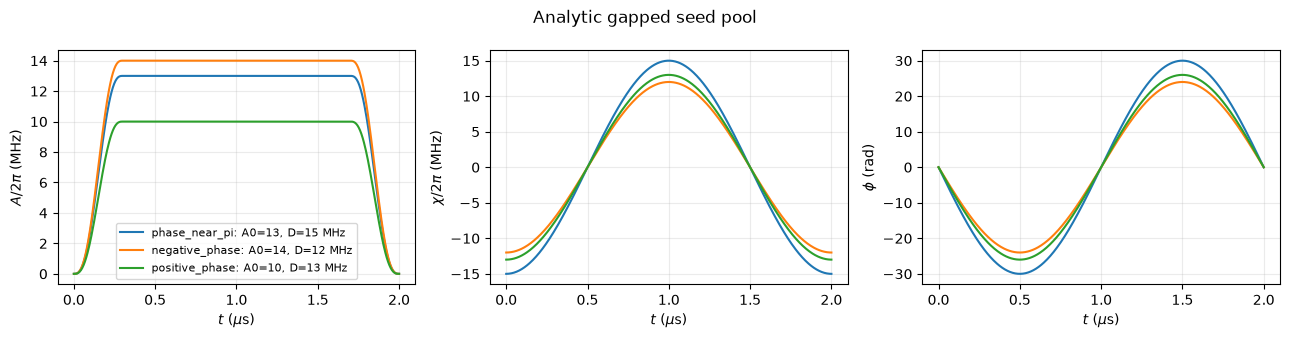

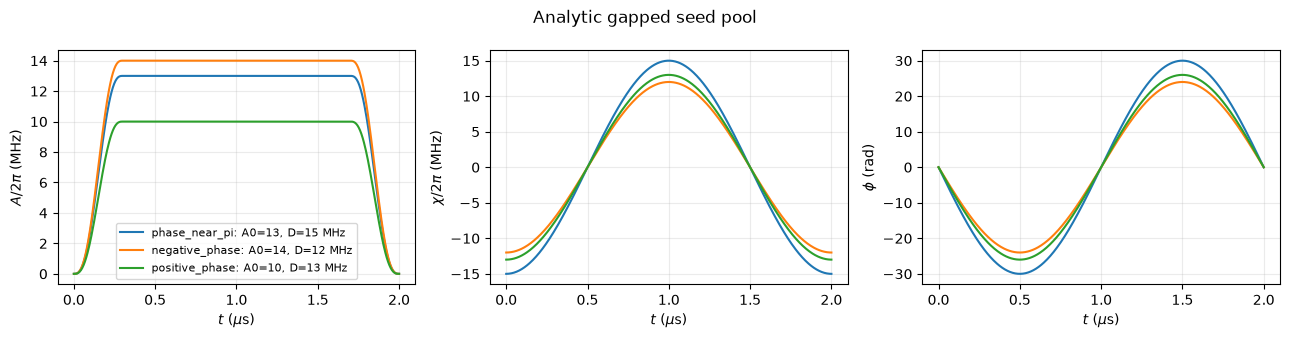

In [2]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.4), sharex=True)
for spec in SEED_SPECS:
    parameters = BASIS.seed(spec["amplitude_MHz"], spec["edge_chirp_MHz"])
    t, amplitude, chirp, phase = pulse_arrays(parameters, INITIAL_DURATION_S)
    label = f'{spec["branch"]}: A0={spec["amplitude_MHz"]:.0f}, D={spec["edge_chirp_MHz"]:.0f} MHz'
    axes[0].plot(t / 1e-6, amplitude / MHz, label=label)
    axes[1].plot(t / 1e-6, chirp / MHz)
    axes[2].plot(t / 1e-6, phase)

axes[0].set_ylabel(r"$A/2\pi$ (MHz)")
axes[1].set_ylabel(r"$\chi/2\pi$ (MHz)")
axes[2].set_ylabel(r"$\phi$ (rad)")
for ax in axes:
    ax.set_xlabel(r"$t$ ($\mu$s)")
    ax.grid(alpha=0.25)
axes[0].legend(fontsize=8)
fig.suptitle("Analytic gapped seed pool")
fig.tight_layout()
display(fig)

## 4. Finite-$V_{rr}$ spline-GRAPE through the `qoc` seam

The search Hamiltonian is the bilinear control model exported by
`ryd_gate.bilinear_control_model` (ADR-0024): the same compiler that serves
`simulate` supplies $h_0$ with the geometry-resolved blockade and the Hermitian
channel operators, so no hand-built matrices remain. Propagation and the
analytic gradient live in `qoc.grape`: piecewise-constant midpoint slices
(1 ns cap) with the discrete adjoint — forward states, backward costates
through the same slice propagators, exact Fréchet slice derivatives — pulled
back through the spline coordinates by the study-side `control_pullback`, so
the gradient cost stays independent of the number of coordinates. At 1 ns the
endpoint amplitudes agree with the previous CF4 engine to $\sim2\times10^{-5}$
on the seed pool, far below both acceptance thresholds. The grid contains the
envelope breakpoints and spline knots, and the selected pulse is re-evaluated
once with every step bisected.

*Implementation: `propagation_grid()`, `bisect_grid()` and `search_evaluation()` in `scripts/adiabatic_01r_optimization.py`.*

## 5. Endpoint objective

For $b\in\{00,01,10,11\}$, $a_b=\langle b|U(T)|b\rangle$ and $L_b=1-|a_b|^2$.
The smooth return loss is $L_{\rm mean}$; final acceptance uses $L_{\max}$. The
gauge-invariant product is $q=a_{00}a_{11}a_{01}^{*}a_{10}^{*}$. To avoid
rewarding phase carried by a leaky amplitude, the search uses

$$
S_\phi=\frac{|q|-\operatorname{Re}q}{2}=|q|\,C_\phi^2,\qquad
P_\phi=\max\!\left(0,1-\frac{S_\phi}{0.25}\right)^2,
$$

and minimizes $J=L_{\rm mean}+P_\phi$. Once the minimum entangling threshold is
met, $P_\phi=0$; no preferred target angle such as $\pi$ remains.

*Implementation: `gate_metrics()` and `objective_costates()` in `scripts/adiabatic_01r_optimization.py`.*

## 6. One fixed-duration optimization stage

`qoc.minimize` (method `"l-bfgs-b"`) receives the analytic gradient and the
per-iteration recorder through its method options; a study-side memo shares one
`value_and_grad` propagation between the separate loss and gradient calls
(`qoc` itself never caches). Every accepted optimizer iteration is recorded for
diagnostics, not as a candidate archive. Each stage compares only the inherited
seed and the optimizer terminal point: a feasible point beats an infeasible
one; if both pass, lower $L_{\max}$ wins. The selected point is evaluated once
on the bisected propagation grid and its discrepancy recorded. There is no retry,
tolerance gate, or extra optimizer budget; the public exact backend decides
final acceptance.

*Implementation: `optimize_fixed_duration()` and `choose_two_points()` in `scripts/adiabatic_01r_optimization.py`.*

## 7. Public exact-ODE validation and Rydberg exposure

Only the stage-selected pulse is converted back to the physical complex drive
$H_{r1}(t)=\tfrac{A(t)}{2}e^{-i\phi(t)}$, $\phi(t)=\int_0^t\chi(t')\,dt'$. A
single batched public call requests total Rydberg occupation at 301 times for
all four logical inputs; the same results provide the return amplitudes, so
exposure $\mathcal E_b=\int_0^T\langle n_{r,0}+n_{r,1}\rangle_b\,dt$ needs no
second evolution. Exact validation is far slower than a GRAPE evaluation and is
never run inside L-BFGS-B.

*Implementation: `physical_protocol()` and `exact_validate()` in `scripts/adiabatic_01r_optimization.py`.*

## 8. Result schema, caching, and atomic persistence

One human-readable artifact, `results/01r_adiabatic_optimization/result.json`,
is sufficient to recreate every table and figure without recomputation. Waveforms
are reconstructed from the 17 saved spline coordinates; no dense trajectories,
sampled waveforms, NPZ, or PNG files are stored. Only finite JSON is written
(`allow_nan=False`).

`serialize_stage` defines the **single** stage shape used by both fresh and
cached runs, so `stages` always holds plain JSON-safe records. `write_result`
replaces the file atomically and is called after every completed branch or
continuation attempt, so a later exception cannot discard in-memory history. A
partial run is flagged by `complete=False`.

*Implementation: `serialize_stage()`, `build_config()`, `build_payload()` and `write_result()` in `scripts/adiabatic_01r_optimization.py`.*

## 9. Duration-ladder continuation (opt-in)

With `RUN_CONTINUATION=True`, each baseline branch is continued down a fixed
duration ladder: $0.1\,\mu\mathrm{s}$ steps from $1.9\,\mu\mathrm{s}$ to
$0.5\,\mu\mathrm{s}$ (16 stages per branch including the baseline). The
normalized coordinates are inherited unchanged: the $s=t/T$ parametrization
scales the pulse shape proportionally with $T$, so pulse area shrinks with
duration and is never rescaled automatically.

Each stage inherits the previous stage's *selected* coordinates and proceeds to
the next duration **regardless of acceptance** — stages are marked
accepted/failed but the branch never stalls. When neither the inherited seed
nor the optimizer terminal is feasible on the propagation grid, the lower-$J$ point
is selected, exact-validated, and carried forward. The purpose is diagnostic:
at every duration decrease the inherited pulse is less adiabatic (more residual
Rydberg population at the endpoint), so its objective $J$ should visibly jump
up before the optimizer pulls it back down.

The ladder does not prove a quantum speed limit. A failed duration of interest
can be manually retried with a richer $K=12$ spline basis (section 11
template).

*Implementation: `ladder_branch()` in `scripts/adiabatic_01r_optimization.py`.*

## 10. Run or replay the three $T=2\,\mu\mathrm{s}$ branches

If `result.json` exists with the current `SCHEMA_VERSION` and
`FORCE_RECOMPUTE=False`, `study.load_or_compute` loads it and skips all
optimizer / exact_ode / ARC work. A cached result with an older schema (e.g. the pre-`qoc` CF4
engine, schema 3) is recomputed automatically. Otherwise it optimizes each
seed, records the bisected-grid discretization discrepancy, runs one complete
public exact validation, and atomically rewrites `result.json` after each
branch (and each continuation attempt), marking `complete=True` only at the
end.

*Implementation: `load_or_compute()` and `compute_result()` in `scripts/adiabatic_01r_optimization.py`.*

In [3]:
config, history, stages = study.load_or_compute(
    RESULT_PATH, force=FORCE_RECOMPUTE, run_continuation=RUN_CONTINUATION)
print(f"V_rr/2pi = {config['V_RR_rad_s'] / MHz:.6f} MHz")
print(f"{len(stages)} stage(s), {sum(s['accepted'] for s in stages)} accepted")

Loaded cached complete result from results/01r_adiabatic_optimization/result.json
  48 stage(s), 1015 optimizer iteration(s); no minimize / exact_ode / ARC calls.
V_rr/2pi = 210.626400 MHz
48 stage(s), 46 accepted


In [4]:
def summary_table(stage_records):
    header = (
        "| branch | T (us) | source | exact Lmax | Cphi | PhiZZ (rad) | "
        "max exposure (us) | accepted |\n"
        "|---|---:|---|---:|---:|---:|---:|:---:|"
    )
    rows = [header]
    for stage in stage_records:
        exact = stage.get("exact_metrics")
        if exact is None:
            rows.append(
                f'| {stage["branch"]} | {stage["duration_s"] / 1e-6:.4f} | '
                f'— | — | — | — | — | no |')
            continue
        rows.append(
            f'| {stage["branch"]} | {stage["duration_s"] / 1e-6:.4f} | '
            f'{stage["selected_source"]} | {exact["L_max"]:.3e} | '
            f'{exact["C_phi"]:.6f} | {exact["Phi_ZZ"]:+.6f} | '
            f'{exact["exposure_max_s"] / 1e-6:.6f} | '
            f'{"yes" if stage["accepted"] else "no"} |')
    return "\n".join(rows)


display(Markdown(summary_table(stages)))

| branch | T (us) | source | exact Lmax | Cphi | PhiZZ (rad) | max exposure (us) | accepted |
|---|---:|---|---:|---:|---:|---:|:---:|
| phase_near_pi | 2.0000 | optimized | 2.038e-10 | 0.997405 | +2.997489 | 0.955462 | yes |
| negative_phase | 2.0000 | optimized | 1.988e-09 | 0.565606 | -1.202336 | 0.942520 | yes |
| positive_phase | 2.0000 | optimized | 4.224e-11 | 0.863124 | +2.082847 | 0.962135 | yes |
| phase_near_pi | 1.9000 | optimized | 9.148e-14 | 0.979856 | -2.739478 | 0.238277 | yes |
| phase_near_pi | 1.8000 | optimized | 6.041e-09 | 0.972806 | -2.674109 | 0.227335 | yes |
| phase_near_pi | 1.7000 | optimized | 1.920e-09 | 0.985592 | -2.801683 | 0.220702 | yes |
| phase_near_pi | 1.6000 | optimized | 1.034e-09 | 0.989848 | -2.856370 | 0.211532 | yes |
| phase_near_pi | 1.5000 | optimized | 2.826e-10 | 0.959463 | -2.570184 | 0.194341 | yes |
| phase_near_pi | 1.4000 | optimized | 8.532e-10 | 0.975192 | -2.695173 | 0.186743 | yes |
| phase_near_pi | 1.3000 | optimized | 3.900e-10 | 0.948749 | -2.498506 | 0.171835 | yes |
| phase_near_pi | 1.2000 | optimized | 3.267e-12 | 0.976582 | -2.707910 | 0.167025 | yes |
| phase_near_pi | 1.1000 | optimized | 1.576e-10 | 0.991192 | -2.875954 | 0.159331 | yes |
| phase_near_pi | 1.0000 | optimized | 1.120e-09 | 0.999940 | -3.119653 | 0.152129 | yes |
| phase_near_pi | 0.9000 | optimized | 8.653e-11 | 0.997205 | -2.992037 | 0.139161 | yes |
| phase_near_pi | 0.8000 | optimized | 2.567e-04 | 0.500072 | -1.047363 | 0.205802 | no |
| phase_near_pi | 0.7000 | optimized | 4.615e-11 | 0.998392 | +3.028171 | 0.112493 | yes |
| phase_near_pi | 0.6000 | optimized | 1.116e-10 | 0.996782 | -2.981093 | 0.098020 | yes |
| phase_near_pi | 0.5000 | optimized | 8.492e-11 | 0.969038 | -2.642610 | 0.085887 | yes |
| negative_phase | 1.9000 | optimized | 9.498e-10 | 0.992994 | -2.904706 | 0.893592 | yes |
| negative_phase | 1.8000 | optimized | 4.670e-13 | 0.757334 | -1.718443 | 0.208317 | yes |
| negative_phase | 1.7000 | optimized | 6.241e-09 | 0.996861 | -2.983080 | 0.242717 | yes |
| negative_phase | 1.6000 | optimized | 2.731e-09 | 0.996915 | -2.984459 | 0.232076 | yes |
| negative_phase | 1.5000 | optimized | 8.184e-10 | 0.997011 | -2.986923 | 0.220720 | yes |
| negative_phase | 1.4000 | optimized | 1.151e-09 | 0.999030 | -3.053506 | 0.210266 | yes |
| negative_phase | 1.3000 | optimized | 2.303e-12 | 0.992845 | -2.902204 | 0.195109 | yes |
| negative_phase | 1.2000 | optimized | 6.941e-10 | 0.958758 | -2.565200 | 0.175626 | yes |
| negative_phase | 1.1000 | optimized | 7.214e-10 | 0.992646 | -2.898884 | 0.170511 | yes |
| negative_phase | 1.0000 | optimized | 2.052e-11 | 0.999977 | +3.128061 | 0.162849 | yes |
| negative_phase | 0.9000 | optimized | 2.258e-10 | 0.995642 | +2.954807 | 0.152864 | yes |
| negative_phase | 0.8000 | optimized | 1.107e-09 | 0.569556 | -1.211932 | 0.180429 | yes |
| negative_phase | 0.7000 | optimized | 8.350e-10 | 0.647597 | +1.408853 | 0.385315 | yes |
| negative_phase | 0.6000 | optimized | 2.584e-09 | 0.641097 | +1.391853 | 0.334678 | yes |
| negative_phase | 0.5000 | optimized | 1.309e-08 | 0.828422 | -1.952570 | 0.294086 | yes |
| positive_phase | 1.9000 | optimized | 5.472e-07 | 0.500005 | -1.047208 | 0.914804 | yes |
| positive_phase | 1.8000 | optimized | 1.820e-08 | 0.510508 | +1.071552 | 0.870280 | yes |
| positive_phase | 1.7000 | optimized | 2.347e-09 | 0.652238 | +1.421066 | 0.834321 | yes |
| positive_phase | 1.6000 | optimized | 5.333e-09 | 0.979294 | -2.733885 | 1.060050 | yes |
| positive_phase | 1.5000 | optimized | 6.637e-09 | 0.521576 | -1.097393 | 0.986239 | yes |
| positive_phase | 1.4000 | optimized | 4.280e-12 | 0.983544 | +2.778260 | 0.138749 | yes |
| positive_phase | 1.3000 | optimized | 1.348e-09 | 0.983720 | +2.780215 | 0.138220 | yes |
| positive_phase | 1.2000 | optimized | 6.082e-09 | 0.998705 | +3.039786 | 0.137298 | yes |
| positive_phase | 1.1000 | optimized | 2.441e-08 | 0.994785 | -2.937254 | 0.137871 | yes |
| positive_phase | 1.0000 | optimized | 1.122e-05 | 0.607737 | +1.306417 | 0.072393 | yes |
| positive_phase | 0.9000 | optimized | 2.934e-08 | 0.599793 | +1.286486 | 0.070213 | yes |
| positive_phase | 0.8000 | optimized | 2.875e-11 | 0.613660 | +1.321374 | 0.070135 | yes |
| positive_phase | 0.7000 | optimized | 1.292e-08 | 0.655098 | +1.428625 | 0.070302 | yes |
| positive_phase | 0.6000 | optimized | 1.027e-08 | 0.685150 | +1.509619 | 0.068240 | yes |
| positive_phase | 0.5000 | optimized | 1.443e-04 | 0.722272 | +1.614163 | 0.063910 | no |

## 11. Diagnostics

The first figure shows the objective and gate metrics over accepted optimizer
iterations. Canonical $\Phi_{ZZ}\in[-\pi,\pi]$ stays stored in `history`; only
the plotted per-branch trace is unwrapped. A thin gray connector joins the end
of each stage to the inherited-seed evaluation at the next (shorter) duration,
so the seed's objective jump at every duration decrease is visible before the
optimizer pulls it down. Durations are on the colorbar; the legend keeps only
the exact-validation markers, with accepted stages as filled markers and failed
attempts as open markers. The second figure reconstructs the
physical $A(t)$ and control phase $\phi(t)$ from every recorded coordinate point;
each duration has one color, accepted iterations are thin, and each selected
pulse is thick (dashed if the attempt was rejected). The horizontal axis is real
physical time, so duration compression moves the pulse endpoint left.

Both figures consume the same JSON-shape `history` and `stages`, so they render
identically after a fresh computation and after a cached reload.

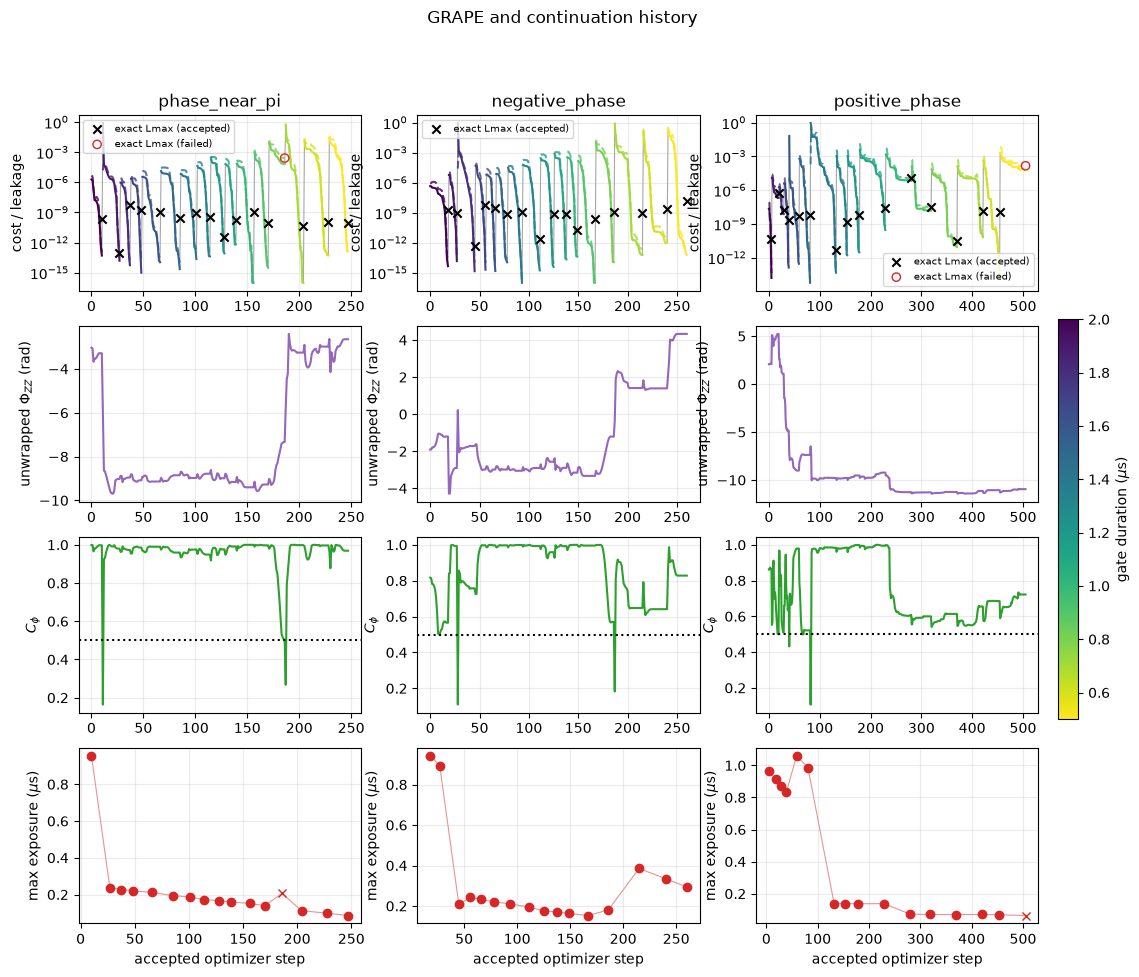

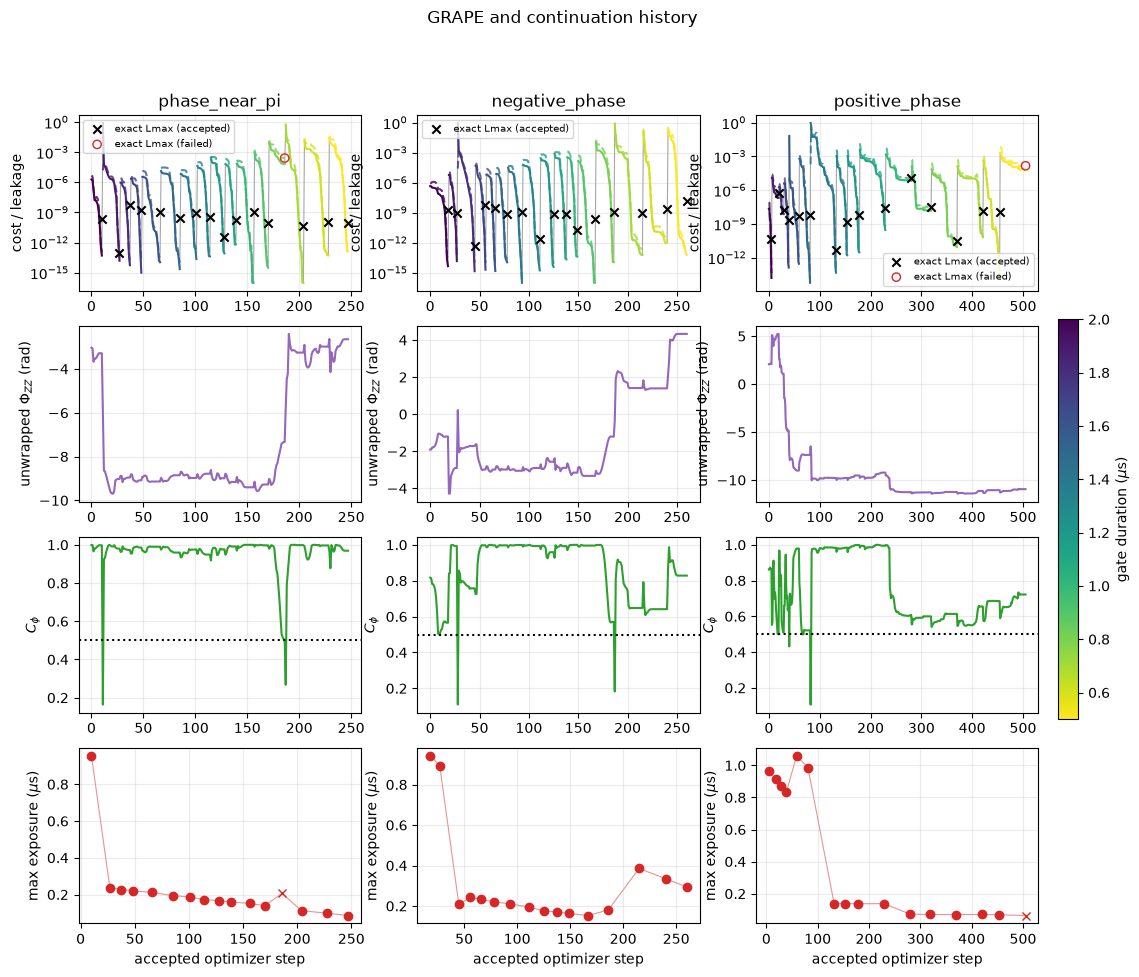

In [5]:
def duration_norm(records):
    durations = np.array([entry["duration_s"] for entry in records])
    low, high = float(np.min(durations)), float(np.max(durations))
    if np.isclose(low, high):
        pad = max(0.05 * high, 1e-12)
        low, high = low - pad, high + pad
    return colors.Normalize(vmin=low / 1e-6, vmax=high / 1e-6)


def _validated_stages(stages, branch):
    return [s for s in stages if s["branch"] == branch and "exact_metrics" in s]


def plot_metric_history(history, stages, basis=BASIS):
    branches = [spec["branch"] for spec in SEED_SPECS]
    norm = duration_norm(history) if history else colors.Normalize(0.0, 1.0)
    cmap = cm.viridis_r
    fig, axes = plt.subplots(
        4, len(branches), figsize=(4.3 * len(branches), 10.5), squeeze=False)

    for column, branch in enumerate(branches):
        records = [r for r in history if r["branch"] == branch]
        group_keys = []
        for record in records:
            key = (record["stage_index"], record["duration_s"])
            if key not in group_keys:
                group_keys.append(key)

        previous_tail = None
        for stage_index, duration_s in group_keys:
            group = [r for r in records
                     if r["stage_index"] == stage_index and r["duration_s"] == duration_s]
            x = np.array([r["branch_iteration"] for r in group])
            j = [max(r["cost"], 1e-16) for r in group]
            color = cmap(norm(duration_s / 1e-6))
            if previous_tail is not None:
                # Seed-jump connector: previous stage's last point to this
                # stage's inherited-seed evaluation at the shorter duration.
                axes[0, column].semilogy(
                    [previous_tail[0], x[0]], [previous_tail[1], j[0]],
                    color="0.65", lw=0.8, zorder=1)
            axes[0, column].semilogy(x, j, color=color)
            axes[0, column].semilogy(
                x, [max(r["L_max"], 1e-16) for r in group], "--", color=color, alpha=0.8)
            previous_tail = (x[-1], j[-1])

        if records:
            phi = np.unwrap([r["Phi_ZZ"] for r in records])
            xr = [r["branch_iteration"] for r in records]
            axes[1, column].plot(xr, phi, color="tab:purple")
            axes[2, column].plot(xr, [r["C_phi"] for r in records], color="tab:green")
        axes[2, column].axhline(C_PHI_ACCEPT, color="black", linestyle=":")

        exposure_points = []
        for stage in _validated_stages(stages, branch):
            x_stage = (stage["history_start"] if stage["selected_source"] == "seed"
                       else stage["history_end"])
            accepted = stage["accepted"]
            axes[0, column].scatter(
                [x_stage], [max(stage["exact_metrics"]["L_max"], 1e-16)],
                marker=("x" if accepted else "o"),
                color=("black" if accepted else "tab:red"),
                facecolors=("black" if accepted else "none"),
                label=("exact Lmax (accepted)" if accepted else "exact Lmax (failed)"),
                zorder=5)
            exposure_points.append(
                (x_stage, stage["exact_metrics"]["exposure_max_s"] / 1e-6, accepted))
        if exposure_points:
            exposure_points.sort()
            axes[3, column].plot(
                [p[0] for p in exposure_points], [p[1] for p in exposure_points],
                color="tab:red", lw=0.8, alpha=0.5, zorder=1)
            for x_stage, exposure, accepted in exposure_points:
                axes[3, column].plot(
                    [x_stage], [exposure], marker=("o" if accepted else "x"),
                    color="tab:red", fillstyle=("full" if accepted else "none"))

        axes[0, column].set_title(branch)
        axes[0, column].set_ylabel("cost / leakage")
        axes[1, column].set_ylabel(r"unwrapped $\Phi_{ZZ}$ (rad)")
        axes[2, column].set_ylabel(r"$C_\phi$")
        axes[3, column].set_ylabel(r"max exposure ($\mu$s)")
        axes[3, column].set_xlabel("accepted optimizer step")
        for row in range(4):
            axes[row, column].grid(alpha=0.25)
        # Durations are on the colorbar; the legend keeps only the deduplicated
        # exact-validation acceptance markers.
        handles, labels = axes[0, column].get_legend_handles_labels()
        unique = dict(zip(labels, handles))
        if unique:
            axes[0, column].legend(unique.values(), unique.keys(), fontsize=7)

    colorbar = fig.colorbar(
        cm.ScalarMappable(norm=norm, cmap=cmap), ax=axes, fraction=0.02, pad=0.02)
    colorbar.set_label(r"gate duration ($\mu$s)")
    fig.suptitle("GRAPE and continuation history")
    return fig


metric_figure = plot_metric_history(history, stages)
display(metric_figure)

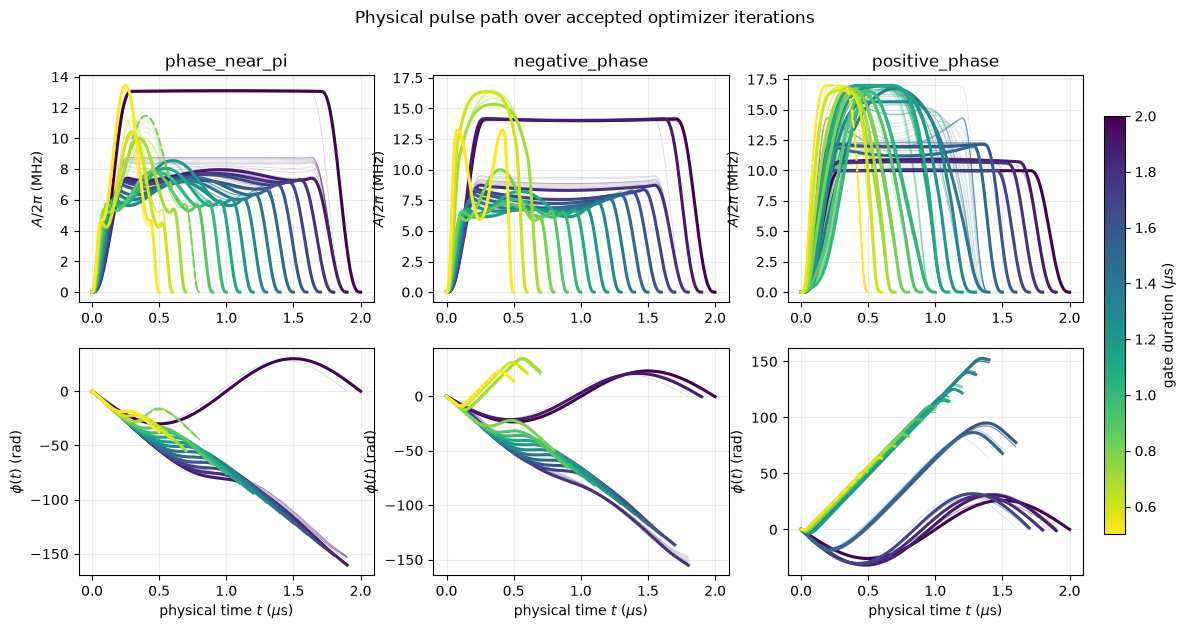

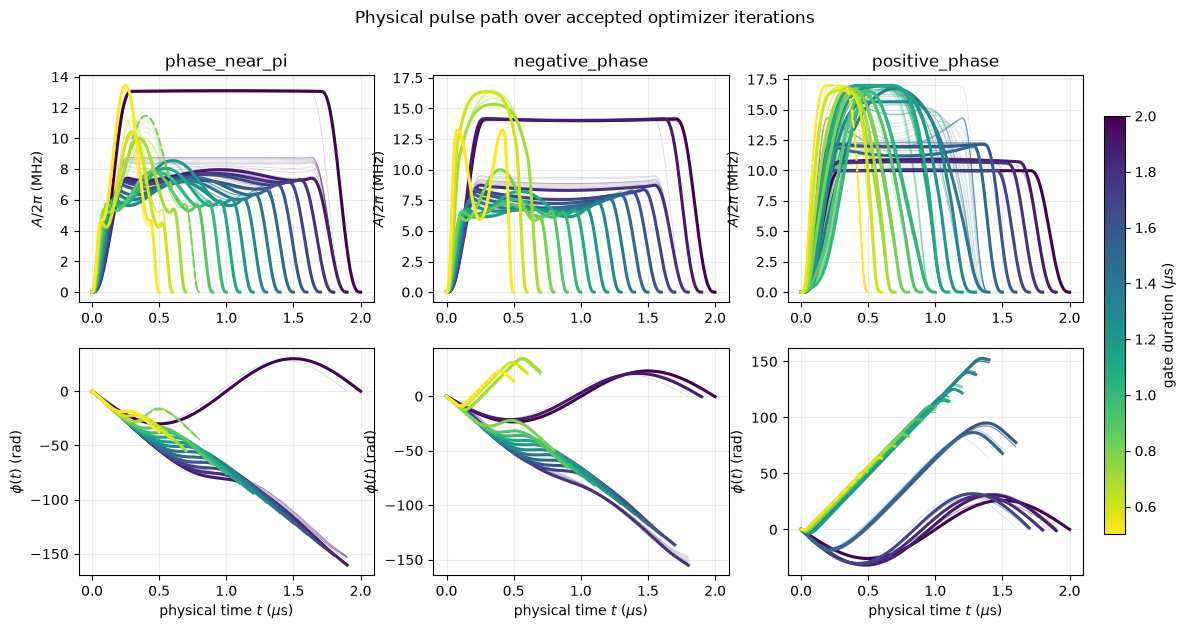

In [6]:
def plot_control_history(history, stages, basis=BASIS):
    branches = [spec["branch"] for spec in SEED_SPECS]
    norm = duration_norm(history) if history else colors.Normalize(0.0, 1.0)
    cmap = cm.viridis_r
    fig, axes = plt.subplots(
        2, len(branches), figsize=(4.5 * len(branches), 6.5), squeeze=False)

    for column, branch in enumerate(branches):
        for record in [r for r in history if r["branch"] == branch]:
            t, amplitude, _chirp, phase = pulse_arrays(
                record["parameters"], record["duration_s"], basis=basis, n_points=241)
            color = cmap(norm(record["duration_s"] / 1e-6))
            axes[0, column].plot(t / 1e-6, amplitude / MHz, color=color, lw=0.55, alpha=0.20)
            axes[1, column].plot(t / 1e-6, phase, color=color, lw=0.55, alpha=0.20)

        for stage in _validated_stages(stages, branch):
            t, amplitude, _chirp, phase = pulse_arrays(
                stage["selected_parameters"], stage["duration_s"], basis=basis, n_points=401)
            color = cmap(norm(stage["duration_s"] / 1e-6))
            style = "-" if stage["accepted"] else "--"
            width = 2.2 if stage["accepted"] else 1.5
            axes[0, column].plot(t / 1e-6, amplitude / MHz, style, color=color, lw=width)
            axes[1, column].plot(t / 1e-6, phase, style, color=color, lw=width)

        axes[0, column].set_title(branch)
        axes[0, column].set_ylabel(r"$A/2\pi$ (MHz)")
        axes[1, column].set_ylabel(r"$\phi(t)$ (rad)")
        axes[1, column].set_xlabel(r"physical time $t$ ($\mu$s)")
        for row in range(2):
            axes[row, column].grid(alpha=0.25)

    colorbar = fig.colorbar(
        cm.ScalarMappable(norm=norm, cmap=cmap), ax=axes, fraction=0.02, pad=0.02)
    colorbar.set_label(r"gate duration ($\mu$s)")
    fig.suptitle("Physical pulse path over accepted optimizer iterations")
    return fig


control_figure = plot_control_history(history, stages)
display(control_figure)

### Optional spline-capacity check

For a failed duration of interest, the stage can be manually retried with
$K=12$ to distinguish a smooth-ansatz limit from the physics. It is
deliberately not automatic. The projection preserves the physical amplitude and
chirp coordinate functions in a least-squares sense.

*Implementation: `project_coordinates()` in `scripts/adiabatic_01r_optimization.py`; the template below
is deliberately inert.*

In [7]:
# Manual capacity-check template (needs a fresh compute with a fresh model):
# model = study.build_search_model()
# BASIS_12 = study.ControlBasis(n_coeffs=12)
# theta_12 = study.project_coordinates(theta_8, BASIS, BASIS_12)
# retry = study.run_stage(theta_12, failed_duration_s, branch="capacity_check",
#                         stage_index=0, basis=BASIS_12, history=[], model=model)

## 12. Reading the outcome

A successful baseline demonstrates a smooth finite-blockade phase gate, not
certified adiabaticity. The search intentionally allows intermediate Rydberg
population and does not penalize exposure. For a chosen stage inspect
`exact_metrics["L_max"]` (worst same-input return loss), `["C_phi"]` (periodic
entangling strength), `["Phi_ZZ"]` (canonical conditional phase), and
`["exposures_s"]` (four logical-input Rydberg exposures). Multiplying an exposure
by a chosen decay rate is a caller-owned first-order estimate; it is not folded
into the optimized endpoint objective.